# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [3]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("/workspaces/ds-fall-2026/Week-05-Business-Stats-Analytics/data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [63]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
print(df.head())
print(df.info())


  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

  Vehicle Size Vehicle Style  highway MPG  city mpg  Popularity   MSRP  
0      Compact         Coupe           26        19        39

In [ ]:
# inspecting duplicated rows.
copy = df.copy()
copy["duplicated_results"] = df.duplicated(keep=False)
copy["group_ID"] = (copy.groupby(list(df.columns), dropna=False).ngroup())
copy.sort_values(["duplicated_results", "group_ID"], ascending=False)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,duplicated_results,group_ID
11601,Volvo,XC60,2017,regular unleaded,302.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr SUV,29,20,870,46350,True,11157
11603,Volvo,XC60,2017,regular unleaded,302.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr SUV,29,20,870,46350,True,11157
11600,Volvo,XC60,2017,regular unleaded,240.0,4.0,AUTOMATIC,front wheel drive,4.0,Midsize,4dr SUV,30,23,870,40950,True,11156
11604,Volvo,XC60,2017,regular unleaded,240.0,4.0,AUTOMATIC,front wheel drive,4.0,Midsize,4dr SUV,30,23,870,40950,True,11156
8918,Volvo,S70,1998,regular unleaded,168.0,5.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,27,17,870,2000,True,11038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,Acura,CL,2003,premium unleaded (required),225.0,6.0,AUTOMATIC,front wheel drive,2.0,Midsize,Coupe,27,17,204,28200,False,4
2699,Acura,CL,2002,premium unleaded (required),225.0,6.0,AUTOMATIC,front wheel drive,2.0,Midsize,Coupe,27,17,204,30030,False,3
2698,Acura,CL,2002,premium unleaded (required),225.0,6.0,AUTOMATIC,front wheel drive,2.0,Midsize,Coupe,27,17,204,28030,False,2
2696,Acura,CL,2001,premium unleaded (required),225.0,6.0,AUTOMATIC,front wheel drive,2.0,Midsize,Coupe,27,17,204,29980,False,1


In [61]:
df["MSRP"].describe()
sussyPriceCond = df["MSRP"] == 2000
df[sussyPriceCond].value_counts()

Make    Model      Year  Engine Fuel Type  Engine HP  Engine Cylinders  Transmission Type  Driven_Wheels      Number of Doors  Vehicle Size  Vehicle Style       highway MPG  city mpg  Popularity  MSRP
Dodge   RAM 150    1991  regular unleaded  125.0      6.0               UNKNOWN            rear wheel drive   2.0              Large         Regular Cab Pickup  17           12        1851        2000    8
GMC     S-15       1990  regular unleaded  105.0      4.0               MANUAL             rear wheel drive   2.0              Compact       Regular Cab Pickup  25           21        549         2000    7
                                           160.0      6.0               MANUAL             four wheel drive   2.0              Compact       Regular Cab Pickup  19           15        549         2000    6
Ford    Bronco II  1990  regular unleaded  140.0      6.0               MANUAL             rear wheel drive   2.0              Compact       2dr SUV             20           16     

In [62]:
df["Number of Doors"].value_counts()

Number of Doors
4.0    8353
2.0    3160
3.0     395
Name: count, dtype: int64

In [68]:
df.info()
nullValuesCond = df["Engine HP"].isna()
electricEngineCond = df["Engine Fuel Type"] == "electric"
df[nullValuesCond & electricEngineCond]
df[nullValuesCond & ~electricEngineCond]

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  str    
 10  Vehicle Style      11914 non-null  str    
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 1.4 MB


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
2905,Lincoln,Continental,2017,premium unleaded (recommended),NaN,6.0,AUTOMATIC,all wheel drive,4.0,Large,Sedan,25,17,61,55915
2906,Lincoln,Continental,2017,premium unleaded (recommended),NaN,6.0,AUTOMATIC,front wheel drive,4.0,Large,Sedan,27,18,61,62915
2907,Lincoln,Continental,2017,premium unleaded (recommended),NaN,6.0,AUTOMATIC,front wheel drive,4.0,Large,Sedan,27,18,61,53915
2908,Lincoln,Continental,2017,premium unleaded (recommended),NaN,6.0,AUTOMATIC,all wheel drive,4.0,Large,Sedan,25,17,61,64915
4203,Ford,Escape,2017,regular unleaded,NaN,4.0,AUTOMATIC,front wheel drive,4.0,Compact,4dr SUV,30,23,5657,29100
4204,Ford,Escape,2017,regular unleaded,NaN,4.0,AUTOMATIC,all wheel drive,4.0,Compact,4dr SUV,28,22,5657,30850
4205,Ford,Escape,2017,regular unleaded,NaN,4.0,AUTOMATIC,all wheel drive,4.0,Compact,4dr SUV,28,22,5657,26850
4206,Ford,Escape,2017,regular unleaded,NaN,4.0,AUTOMATIC,front wheel drive,4.0,Compact,4dr SUV,30,23,5657,25100
4914,Ford,Freestar,2005,regular unleaded,NaN,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Passenger Minivan,22,16,5657,28030
4915,Ford,Freestar,2005,regular unleaded,NaN,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Passenger Minivan,22,16,5657,23930


In [74]:
df.info()
df[df["Engine Fuel Type"].isna()]
df[df["Engine Cylinders"].isna()]
df[df["Number of Doors"].isna()]


<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  str    
 10  Vehicle Style      11914 non-null  str    
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 1.4 MB


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
4666,Ferrari,FF,2013,premium unleaded (required),651.0,12.0,AUTOMATED_MANUAL,all wheel drive,NaN,Large,Coupe,16,11,2774,295000
6930,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,105,102,1391,79500
6931,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,101,98,1391,66000
6932,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,105,92,1391,134500
6933,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,rear wheel drive,NaN,Large,Sedan,100,97,1391,74500
6934,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,107,101,1391,71000


In [82]:
df["highway MPG"].describe()
df["highway MPG"].value_counts()
df.sort_values("highway MPG", ascending=False)
audiAndA6Cond = (df["Make"] == "Audi") & (df["Model"] == "A6")
df[audiAndA6Cond]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1098,Audi,A6,2015,diesel,240.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,38,24,3105,58700
1099,Audi,A6,2015,premium unleaded (recommended),220.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,29,20,3105,50450
1100,Audi,A6,2015,premium unleaded (recommended),220.0,4.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,33,25,3105,44800
1101,Audi,A6,2015,premium unleaded (required),310.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,27,18,3105,60100
1102,Audi,A6,2015,premium unleaded (recommended),220.0,4.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,33,25,3105,48350
1103,Audi,A6,2015,premium unleaded (required),310.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,27,18,3105,56300
1104,Audi,A6,2015,premium unleaded (recommended),220.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,29,20,3105,46900
1105,Audi,A6,2015,diesel,240.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,38,24,3105,62500
1106,Audi,A6,2016,premium unleaded (recommended),252.0,4.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,32,22,3105,52100
1107,Audi,A6,2016,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Midsize,Sedan,35,24,3105,49900


In [ ]:
dropped["Popularity"].describe()
dropped["Popularity"].value_counts()
dropped.groupby("Popularity")
# idk what I'm looking at. choosing something else.
display(dropped.sort_values("Popularity"))


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,sussyPrice,sussyEngines
1989,Spyker,C8,2009,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,18,13,2,209990,False,False
1990,Spyker,C8,2009,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,18,13,2,219990,False,False
4961,Genesis,G80,2017,regular unleaded,311.0,6.0,AUTOMATIC,rear wheel drive,4.0,Large,Sedan,28,18,21,41400,False,False
4963,Genesis,G80,2017,regular unleaded,311.0,6.0,AUTOMATIC,all wheel drive,4.0,Large,Sedan,25,16,21,43900,False,False
4962,Genesis,G80,2017,premium unleaded (recommended),420.0,8.0,AUTOMATIC,rear wheel drive,4.0,Large,Sedan,23,15,21,54550,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10062,Ford,Transit Wagon,2017,flex-fuel (unleaded/E85),275.0,6.0,AUTOMATIC,rear wheel drive,3.0,Midsize,Passenger Van,19,14,5657,34515,False,False
10063,Ford,Transit Wagon,2017,regular unleaded,275.0,6.0,AUTOMATIC,rear wheel drive,3.0,Midsize,Passenger Van,19,14,5657,38015,False,False
3970,Ford,Escape,2016,regular unleaded,168.0,4.0,AUTOMATIC,front wheel drive,4.0,Compact,4dr SUV,31,22,5657,23590,False,False
3971,Ford,Escape,2016,premium unleaded (recommended),178.0,4.0,AUTOMATIC,all wheel drive,4.0,Compact,4dr SUV,29,22,5657,31745,False,False


In [104]:
dropped["Transmission Type"].value_counts(dropna=False)
unknownTransmissionCond = (dropped["Transmission Type"] == "UNKNOWN")
dropped["unknownTransmission"] = unknownTransmissionCond
dropped.sort_values("unknownTransmission", ascending=False)
dropped.loc[unknownTransmissionCond, "Transmission Type"] = np.nan
print(dropped["unknownTransmission"].value_counts())



unknownTransmission
False    11194
Name: count, dtype: int64


In [100]:
# 1st solution.
dropped = df.copy()
dropped = dropped.drop_duplicates(keep='first').reset_index(drop=True)
dropped.info()
# 2nd solution.
dropped["sussyPrice"] = dropped["MSRP"] == 2000
# 3rd solution.
nullHPCond = dropped["Engine HP"].isna()
electricEngineCond = dropped["Engine Fuel Type"] == "electric"
dropped["sussyEngines"] = nullHPCond & ~electricEngineCond
#  4th solution.
sussyMPG = dropped["highway MPG"] == 354
dropped.loc[sussyMPG, "highway MPG"] = 34
# 5th solution.
dropped["unknownTransmission"] = unknownTransmissionCond
dropped.loc[unknownTransmissionCond, "Transmission Type"] = np.nan

<class 'pandas.DataFrame'>
RangeIndex: 11194 entries, 0 to 11193
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11194 non-null  str    
 1   Model              11194 non-null  str    
 2   Year               11194 non-null  int64  
 3   Engine Fuel Type   11191 non-null  str    
 4   Engine HP          11125 non-null  float64
 5   Engine Cylinders   11164 non-null  float64
 6   Transmission Type  11194 non-null  str    
 7   Driven_Wheels      11194 non-null  str    
 8   Number of Doors    11188 non-null  float64
 9   Vehicle Size       11194 non-null  str    
 10  Vehicle Style      11194 non-null  str    
 11  highway MPG        11194 non-null  int64  
 12  city mpg           11194 non-null  int64  
 13  Popularity         11194 non-null  int64  
 14  MSRP               11194 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 1.3 MB


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | There were rows that contained the exact same information, column by column| df.duplicate(), I used some other commands to inspect the sussy rows. | 720 | df.copy().drop_duplicates() | Pretty sure I can safely rows that are identical to each other, since copies don't have any deeper meaning. However, if this database was about, idk, sales of cars, then theoretically a person could have bought a car of the same make, model, year, msrp, etc, more than once. In which case, I'd need to reevaluate whether I'd want to do the same in that scenario.|
| 2 | Some rows have an MSRP of $2,000 | df.describe() | 747 | created a new column, and flagged them as suspicious | idk if they're sussy or not. Idk how to distinguish whether $2,000 is a valid sticker price, or maybe it was in the past but isn't now.|
| 3 | Some rows are missing a listed horsepower value | Inspected df.info() and checked the non-null counts | 25 | flagged them as sussy. | I can buy that electric cars might not have a listed horsepower. However, non-electric cars, I think, should have it listed. But, idk anything abour cars so I'm just flagging it for now.|
| 4 | An audi was secretely an F1!  | df["highway MPG"].describe() | 1 | changed its value from 354 to 34 | I looked at similar makes and models, and another one has a highway mpg of 34. I figured it was a typo.|
| 5 | Cars were missing their transmission values | df["Transmission Type"].value_counts | 12 | replaced them with NAN | idk. I want to create null values, but idk if this is the correct way to do it. That is, if I want to meaningfully select from cars with different transmissions, then I want to exclude these cars without listed transmission values. Setting them to NAN seemed like a... choice.|

In [110]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = dropped.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [109]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 18)
engine_fuel_type      3
engine_hp            69
engine_cylinders     30
transmission_type    12
number_of_doors       6
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Valid prices: 10,447
Mean MSRP (USD): 44,788.67
Median MSRP (USD): 31,870.00
Percent above the mean: 24.45%


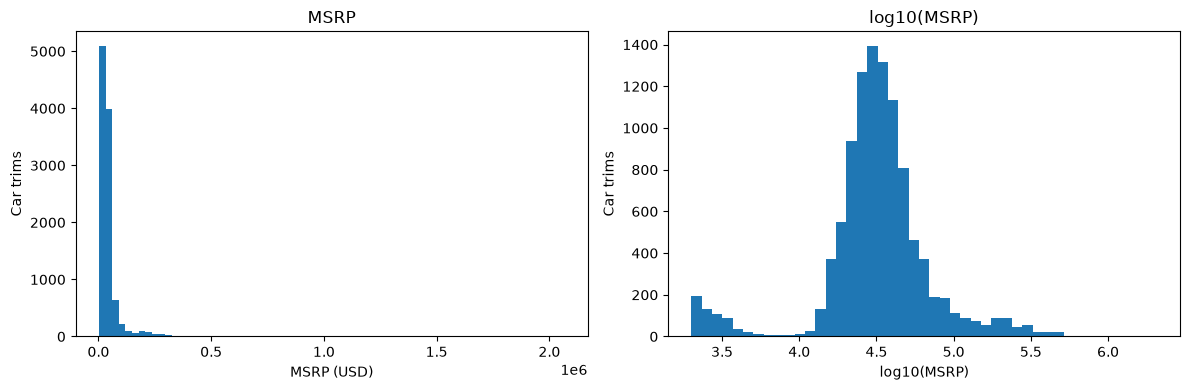

In [115]:
# Q2: use trustworthy MSRP values without deleting flagged records
clean["msrp_valid"] = clean["msrp"].where(~clean["sussyprice"])
clean["highway_mpg_valid"] = clean["highway_mpg"].where(
    clean["engine_fuel_type"] != "electric"
)
prices = clean["msrp_valid"].dropna()
mean_price, median_price = prices.mean(), prices.median()
pct_above = 100 * (prices > mean_price).mean()
print(f"Valid prices: {len(prices):,}")
print(f"Mean MSRP (USD): {mean_price:,.2f}")
print(f"Median MSRP (USD): {median_price:,.2f}")
print(f"Percent above the mean: {pct_above:.2f}%")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices, bins=70)
axes[0].set(title="MSRP", xlabel="MSRP (USD)", ylabel="Car trims")
axes[1].hist(np.log10(prices), bins=45)
axes[1].set(title="log10(MSRP)", xlabel="log10(MSRP)", ylabel="Car trims")
plt.tight_layout()
plt.show()


**Answer:** For the **10,447** non-placeholder prices, the mean MSRP is **$44,788.67** and the median is **$31,870**. The original MSRP distribution has a long right tail, while the log-transformed distribution is much less skewed; just **24.45%** of valid prices exceed the mean. I would put the **median** on the homepage because high-priced luxury cars pull the mean upward.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [117]:
# Q3: 2017 cars, measured against their own size class
cars_2017 = clean.loc[clean["year"] == 2017].copy()
size_stats = cars_2017.groupby("vehicle_size")["highway_mpg_valid"].agg(
    ["count", "mean", "std"]
)
print(size_stats)
civic_z = (42 - size_stats.loc["Compact", "mean"]) / size_stats.loc["Compact", "std"]
volvo_z = (34 - size_stats.loc["Large", "mean"]) / size_stats.loc["Large", "std"]
print(f"Civic z-score (class specified as Compact): {civic_z:.3f}")
print(f"Volvo S90 z-score (Large): {volvo_z:.3f}")
print("Dataset size labels for 42-MPG 2017 Civics:")
print(cars_2017.loc[
    (cars_2017["make"] == "Honda") &
    (cars_2017["model"] == "Civic") &
    (cars_2017["highway_mpg_valid"] == 42),
    "vehicle_size"
].value_counts())


              count       mean       std
vehicle_size                            
Compact         509  30.880157  6.045381
Large           468  22.991453  3.491184
Midsize         639  29.417840  5.451041
Civic z-score (class specified as Compact): 1.839
Volvo S90 z-score (Large): 3.153
Dataset size labels for 42-MPG 2017 Civics:
vehicle_size
Midsize    6
Name: count, dtype: int64


**Answer:** The question's 42-MPG Compact Civic has a z-score of approximately **1.84**, while the 34-MPG Large Volvo S90 has a z-score of **3.15**. The Volvo is therefore more exceptional relative to its size class. **Caveat:** The dataset labels the 42-MPG 2017 Civic as *Midsize*, so I followed the question's *Compact* classification for this comparison.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

2017 n=1624, median (USD)=36,737.50
95% CI (USD): 35,940.00 to 37,682.56
Volvo: n=23, median (USD)=46,350.00
Volvo 95% CI (USD): 41,750.00 to 50,450.00


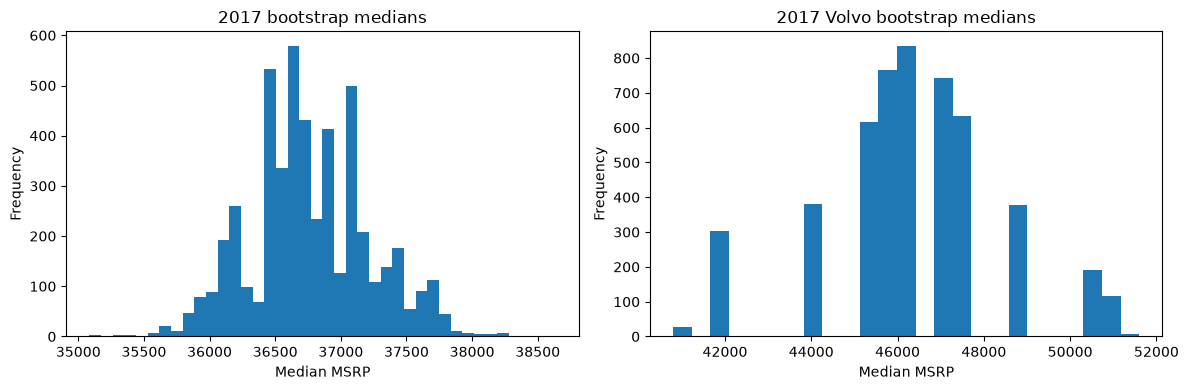

In [118]:
def bootstrap_median(values, n_boot=5000):
    """Compute n_boot bootstrap medians with replacement."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    return np.array([
        np.median(rng.choice(values, size=len(values), replace=True))
        for _ in range(n_boot)
    ])

prices_2017 = cars_2017["msrp_valid"].dropna().to_numpy()
boot_2017 = bootstrap_median(prices_2017)
ci_2017 = np.percentile(boot_2017, [2.5, 97.5])
print(f"2017 n={len(prices_2017)}, median (USD)={np.median(prices_2017):,.2f}")
print(f"95% CI (USD): {ci_2017[0]:,.2f} to {ci_2017[1]:,.2f}")

make = "Volvo"  # Fewer than 50 cars in 2017
make_prices = cars_2017.loc[
    cars_2017["make"] == make, "msrp_valid"
].dropna().to_numpy()
boot_make = bootstrap_median(make_prices)
ci_make = np.percentile(boot_make, [2.5, 97.5])
print(f"{make}: n={len(make_prices)}, median (USD)={np.median(make_prices):,.2f}")
print(f"{make} 95% CI (USD): {ci_make[0]:,.2f} to {ci_make[1]:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_2017, bins=40)
axes[0].set(title="2017 bootstrap medians", xlabel="Median MSRP", ylabel="Frequency")
axes[1].hist(boot_make, bins=25)
axes[1].set(title="2017 Volvo bootstrap medians", xlabel="Median MSRP", ylabel="Frequency")
plt.tight_layout()
plt.show()


**Answer:** The **1,624** valid 2017 prices have a median of **$36,737.50** and a 95% bootstrap interval of approximately **$35,940–$37,683**. For **Volvo (23 cars)**, the median is **$46,350** and the interval is wider, about **$41,750–$50,450**, because the sample is much smaller. For the manager, a similarly collected set of 2017 trims would be expected to give a typical median near **$36,000–$38,000**, assuming the sample represents the market.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Compact trim n=509, mean=30.880, std=6.045
Trim-level t=3.285, p=0.00054568


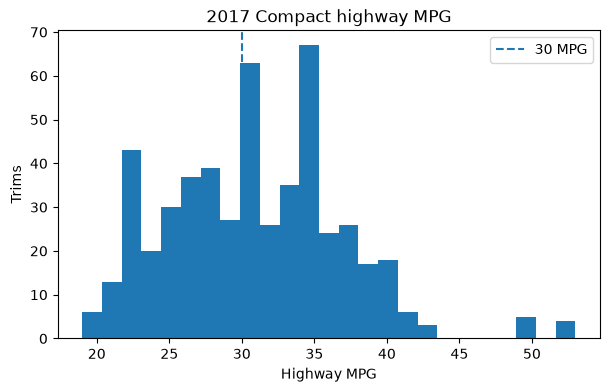

Independent make/model groups: 85
make        model   
Toyota      Tacoma      27
Chevrolet   Corvette    24
Nissan      Frontier    22
            370Z        17
Porsche     911         14
Honda       Civic       13
Audi        A3          12
Volkswagen  Golf GTI    10
Nissan      Juke        10
Chevrolet   Sonic       10
dtype: int64
Model-level n=85, mean=31.685
Model-level t=2.577, p=0.00585134


In [119]:
# Q5: H0: mean <= 30 MPG; Ha: mean > 30 MPG (one-sided)
compacts = cars_2017.loc[
    (cars_2017["vehicle_size"] == "Compact") &
    cars_2017["highway_mpg_valid"].notna(),
    ["make", "model", "highway_mpg_valid"]
]
compact_mpg = compacts["highway_mpg_valid"]
print(f"Compact trim n={len(compact_mpg)}, mean={compact_mpg.mean():.3f}, std={compact_mpg.std():.3f}")
trim_test = stats.ttest_1samp(compact_mpg, popmean=30, alternative="greater")
print(f"Trim-level t={trim_test.statistic:.3f}, p={trim_test.pvalue:.6g}")
plt.figure(figsize=(7, 4))
plt.hist(compact_mpg, bins=25)
plt.axvline(30, linestyle="--", label="30 MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Trims")
plt.title("2017 Compact highway MPG")
plt.legend()
plt.show()

rows_per_model = compacts.groupby(["make", "model"]).size().sort_values(ascending=False)
print("Independent make/model groups:", len(rows_per_model))
print(rows_per_model.head(10))
model_means = compacts.groupby(["make", "model"])["highway_mpg_valid"].mean()
model_test = stats.ttest_1samp(model_means, popmean=30, alternative="greater")
print(f"Model-level n={len(model_means)}, mean={model_means.mean():.3f}")
print(f"Model-level t={model_test.statistic:.3f}, p={model_test.pvalue:.6g}")


**Answer:** For **H₀: μ ≤ 30 MPG** versus **Hₐ: μ > 30 MPG**, the **509** Compact trims average **30.88 MPG**, and the one-sided t-test supports the claim (**p = 0.000546**). The histogram is moderately right-skewed, but the sample is large; still, trim records are not independent because they represent only **85** make–model groups. Averaging once per model gives **31.69 MPG** and **p = 0.00585**, still supporting the claim with a more credible independence assumption.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [120]:
# Q6: compare prices, then control for year and vehicle size
trans = clean.loc[
    clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"]) &
    clean["msrp_valid"].notna()
].copy()
print("All years: price and model year by transmission")
print(trans.groupby("transmission_type").agg(
    n=("msrp_valid", "size"),
    median_msrp=("msrp_valid", "median"),
    median_year=("year", "median"),
    mean_year=("year", "mean")
))
recent = trans.loc[trans["year"].between(2015, 2017)]
print("2015-2017 prices by transmission")
print(recent.groupby("transmission_type")["msrp_valid"].agg(["size", "median"]))
print("2015-2017 prices within vehicle-size classes")
print(recent.pivot_table(
    index="vehicle_size", columns="transmission_type",
    values="msrp_valid", aggfunc=["size", "median"]
))

compact_recent = recent.loc[recent["vehicle_size"] == "Compact"]
auto = compact_recent.loc[
    compact_recent["transmission_type"] == "AUTOMATIC", "msrp_valid"
]
manual = compact_recent.loc[
    compact_recent["transmission_type"] == "MANUAL", "msrp_valid"
]
u_test = stats.mannwhitneyu(auto, manual, alternative="two-sided")
print(f"2015-2017 Compact automatic: n={len(auto)}, median (USD)={auto.median():,.0f}")
print(f"2015-2017 Compact manual: n={len(manual)}, median (USD)={manual.median():,.0f}")
print(f"Mann-Whitney U={u_test.statistic:.1f}, p={u_test.pvalue:.5f}")


All years: price and model year by transmission
                      n  median_msrp  median_year    mean_year
transmission_type                                             
AUTOMATIC          7635      33620.0       2015.0  2012.533857
MANUAL             2184      21875.0       2011.0  2009.136905
2015-2017 prices by transmission
                   size   median
transmission_type               
AUTOMATIC          4511  37065.0
MANUAL              813  26905.0
2015-2017 prices within vehicle-size classes
                       size           median         
transmission_type AUTOMATIC MANUAL AUTOMATIC   MANUAL
vehicle_size                                         
Compact                1119    589   25995.0  25860.0
Large                  1473     26   44400.0  38395.0
Midsize                1919    198   37980.0  26920.0
2015-2017 Compact automatic: n=1119, median (USD)=25,995
2015-2017 Compact manual: n=589, median (USD)=25,860
Mann-Whitney U=317261.0, p=0.20483


**Answer:** Across all years, manuals have a lower median MSRP (**$21,875**) than automatics (**$33,620**), but manual vehicles are older on average (**2009.1** versus **2012.5**). Within 2015–2017 Compact cars, the medians are only **$135 apart** (**$25,860 manual**, **$25,995 automatic**) and the Mann–Whitney test gives **p = 0.205**, not convincing evidence of a difference. Thus the salesperson's overall comparison is confounded by age and class, and I would not assume manuals are automatically cheaper.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [121]:
# Q7: Welch t-test for 4-door versus 2-door MPG
mpg_sample = clean.loc[
    clean["highway_mpg_valid"].notna() &
    clean["number_of_doors"].isin([2.0, 4.0])
]
mpg_2door = mpg_sample.loc[
    mpg_sample["number_of_doors"] == 2, "highway_mpg_valid"
].to_numpy()
mpg_4door = mpg_sample.loc[
    mpg_sample["number_of_doors"] == 4, "highway_mpg_valid"
].to_numpy()
welch = stats.ttest_ind(mpg_4door, mpg_2door, equal_var=False)
mpg_diff = mpg_4door.mean() - mpg_2door.mean()
print(f"2-door: n={len(mpg_2door)}, mean={mpg_2door.mean():.3f}")
print(f"4-door: n={len(mpg_4door)}, mean={mpg_4door.mean():.3f}")
print(f"Difference={mpg_diff:.3f} MPG; Welch p={welch.pvalue:.4g}")

cost_2door = 12000 * 3.50 / mpg_2door.mean()
cost_4door = 12000 * 3.50 / mpg_4door.mean()
savings = cost_2door - cost_4door
print(f"Annual cost 2-door (USD): {cost_2door:,.2f}")
print(f"Annual cost 4-door (USD): {cost_4door:,.2f}")
print(f"Annual savings (USD): {savings:,.2f}")

n_sims, hits = 1000, 0
for _ in range(n_sims):
    sample_4 = rng.choice(mpg_4door, 30, replace=False)
    sample_2 = rng.choice(mpg_2door, 30, replace=False)
    test = stats.ttest_ind(sample_4, sample_2, equal_var=False)
    hits += (test.pvalue < 0.05)
print(f"Significant simulations: {hits}/{n_sims} = {hits/n_sims:.1%}")


2-door: n=2873, mean=25.257
4-door: n=7898, mean=26.806
Difference=1.549 MPG; Welch p=1.936e-32
Annual cost 2-door (USD): 1,662.94
Annual cost 4-door (USD): 1,566.83
Annual savings (USD): 96.10
Significant simulations: 161/1000 = 16.1%


**Answer:** Four-door cars average **26.81** highway MPG versus **25.26** for two-door cars, a statistically detectable difference of **1.55 MPG** (Welch **p ≈ 1.94 × 10⁻³²**). At 12,000 miles per year and $3.50 per gallon, the difference is just **about $96 per year**; with only 30 cars per group, the fraction of significant tests is much lower (see the simulation output). I would discuss fuel costs among comparable vehicles rather than claim that four doors cause efficiency.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Across all model years, manuals appear cheaper ($21,875 median MSRP versus $33,620 for automatics), but manual trims are also older on average. Among 2015–2017 Compact cars, the medians are only $135 apart ($25,860 manual versus $25,995 automatic), and the difference is not convincing statistically (p = 0.205). For a homepage typical price, I recommend the $31,870 median rather than the $44,789 mean, since luxury cars inflate the average. I excluded 747 suspicious $2,000 list prices from price calculations but kept those cars' other specifications. This dataset contains historical manufacturer sticker prices rather than current sale prices, so the results should not be presented as today's market prices.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

Pearson(HP, MSRP)=0.650
Pearson(HP, log10 MSRP)=0.698
Spearman(HP, MSRP)=0.822


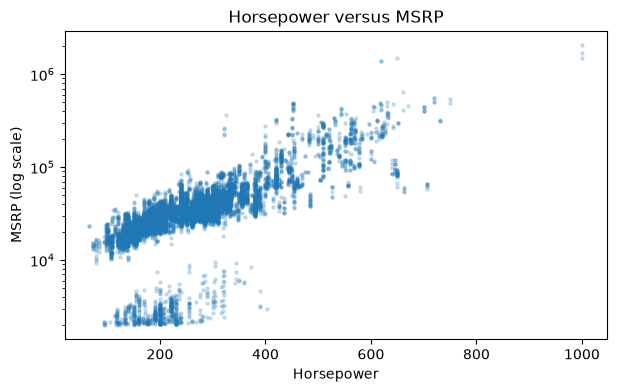

In [122]:
# Optional S1: horsepower correlations and logarithmic scatter plot
hp_price = clean[["engine_hp", "msrp_valid"]].dropna()
pearson_raw = hp_price["engine_hp"].corr(hp_price["msrp_valid"], method="pearson")
pearson_log = hp_price["engine_hp"].corr(np.log10(hp_price["msrp_valid"]), method="pearson")
spearman = hp_price["engine_hp"].corr(hp_price["msrp_valid"], method="spearman")
print(f"Pearson(HP, MSRP)={pearson_raw:.3f}")
print(f"Pearson(HP, log10 MSRP)={pearson_log:.3f}")
print(f"Spearman(HP, MSRP)={spearman:.3f}")
plt.figure(figsize=(7, 4))
plt.scatter(hp_price["engine_hp"], hp_price["msrp_valid"], s=5, alpha=0.2)
plt.yscale("log")
plt.xlabel("Horsepower")
plt.ylabel("MSRP (log scale)")
plt.title("Horsepower versus MSRP")
plt.show()
# Pearson, log-Pearson, Spearman: approximately 0.650, 0.698, 0.822.
# Different price scales/outliers change linear correlation; brand and
# vehicle class are confounders, so this does NOT show causation.


### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [123]:
# Optional S2: association between size and transmission (2015-2017)
table = pd.crosstab(recent["vehicle_size"], recent["transmission_type"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(table)
print(f"Chi-square={chi2:.3f}, df={dof}, p={p:.4g}")
# A strong association supports the confounding concern in Q6.


transmission_type  AUTOMATIC  MANUAL
vehicle_size                        
Compact                 1119     589
Large                   1473      26
Midsize                 1919     198
Chi-square=756.929, df=2, p=4.315e-165
